### Project 5: Distributed Recommender System with Spark
**Author:** Nana Y. Frimpong

This project builds on Project 3, where I implemented matrix factorization for the wine and food pairing recommender using three methods: a baseline bias model, Truncated SVD, and Funk SVD (SGD based factorization). Here I adapt that same recommender to run on Apache Spark using PySpark and MLlib's ALS algorithm, then compare performance against the original single node implementation.

### Assignment Goal

1. Reload the same dataset and problem setup from Project 3
2. Re-run the baseline, Truncated SVD, and Funk SVD models to get fresh timing and RMSE numbers on this machine
3. Adapt the recommender to Spark using `pyspark.ml.recommendation.ALS`, which is the distributed equivalent of Funk SVD since both factor the matrix from observed ratings only
4. Compare runtime and RMSE across all four approaches
5. Discuss at what point moving to Spark would actually be worth it for this kind of data and algorithm

### Dataset

Same as Project 3, the Wine and Food Pairing Dataset from Kaggle (El-Husseini, W.). Each row scores how well a `wine_type` pairs with a `food_item` on a 1 to 5 scale. The raw file has 34,933 rows, but that is because each wine-food combo shows up dozens of times (different cuisines/descriptions). Before modeling, I collapse this down to one rating per (wine, food) pair by averaging, which gives a much smaller and more realistic ratings matrix to work with.

### Environment Setup

My machine came with Java version 26 installed by default, but Spark does not work with it yet. Spark was built for Java versions up to about 17, so I need to point to a different Java installation before I can use PySpark.

I installed Java 17 separately using Homebrew, without replacing the default Java version. Then I set the `JAVA_HOME` environment variable to point to that Java 17 installation. This has to be done before any `pyspark` import in this notebook.

In [15]:
import os
JAVA_17_HOME = '/opt/homebrew/Cellar/openjdk@17/17.0.19/libexec/openjdk.jdk/Contents/Home'
if os.path.exists(JAVA_17_HOME):
    os.environ['JAVA_HOME'] = JAVA_17_HOME

print("JAVA_HOME set to:", os.environ.get('JAVA_HOME'))

JAVA_HOME set to: /opt/homebrew/Cellar/openjdk@17/17.0.19/libexec/openjdk.jdk/Contents/Home


In [29]:
## Importing Libraries
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse.linalg import svds
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Random seed for reproducibility (same seed as Project 3)
np.random.seed(612)

# Loading the dataset
DATA_PATH = '/Users/nanafrimpong/Desktop/SPS Summer 2026/Data 612/Unit 2/Project 3/wine_food_pairings.csv'
if not os.path.exists(DATA_PATH):
    DATA_PATH = os.path.join('data', 'wine_food_pairings.csv')
    if not os.path.exists(DATA_PATH):
        for root, dirs, files in os.walk('.'):
            if 'wine_food_pairings.csv' in files:
                DATA_PATH = os.path.join(root, 'wine_food_pairings.csv')
                break
        else:
            raise FileNotFoundError(
                f'Cannot find wine_food_pairings.csv. Checked {DATA_PATH} and current directory tree.'
            )

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(34933, 8)


,wine_type,wine_category,food_item,food_category,cuisine,pairing_quality,quality_label,description
0,Syrah/Shiraz,Red,smoked sausage,Smoky BBQ,Spanish,2,Poor,Heuristic pairing assessment.
1,Grenache,Red,charcuterie board,Salty Snack,French,3,Neutral,Heuristic pairing assessment.
2,Madeira,Fortified,lemon tart,Dessert,French,4,Good,Acidic wine balances acidic food.
3,Cabernet Sauvignon,Red,roast lamb,Red Meat,Mexican,5,Excellent,Tannic red complements red meat fat.
4,Viognier,White,duck à l’orange,Poultry,Vietnamese,2,Poor,Heuristic pairing assessment.


### Data Preprocessing

We collapse the data so that each wine and food pair appears only once. We also convert the wine and food names into numeric IDs. This gives the models, including Spark's ALS later on, a numerical format they can actually process.

In [30]:
agg = df.groupby(['wine_type', 'food_item'], as_index=False)['pairing_quality'].mean()

wine_ids = {w: i for i, w in enumerate(sorted(agg['wine_type'].unique()))}
food_ids = {f: i for i, f in enumerate(sorted(agg['food_item'].unique()))}
agg['wine_id'] = agg['wine_type'].map(wine_ids)
agg['food_id'] = agg['food_item'].map(food_ids)

n_wines = len(wine_ids)
n_foods = len(food_ids)

print(f"n_wines={n_wines}, n_foods={n_foods}, n_unique_pairs={len(agg)}")
print(f"Original rows before aggregation: {len(df)}")
agg.head()

n_wines=29, n_foods=38, n_unique_pairs=481
Original rows before aggregation: 34933


,wine_type,food_item,pairing_quality,wine_id,food_id
0,Albariño,alfredo pasta,2.750000,0,3
1,Albariño,bbq brisket,2.646154,0,5
2,Albariño,beef stew,3.000000,0,7
3,Albariño,caprese salad,3.054795,0,8
4,Albariño,carbonara,2.750000,0,9


In [31]:
train_df, test_df = train_test_split(agg, test_size=0.2, random_state=612)
print("train:", train_df.shape, "test:", test_df.shape)

global_mean = train_df['pairing_quality'].mean()
print(f"global mean rating: {global_mean:.4f}")

train: (384, 5) test: (97, 5)
global mean rating: 3.0208


### Model 1: Baseline (global mean + user bias + item bias)

This is our simplest model. To predict a rating for any wine and food pair, we start with the overall average score across all pairings. Then we add an adjustment for the specific wine, whether it tends to score higher or lower than average, and another adjustment for the specific food, whether it tends to score higher or lower than average. That's it. No complex interactions, just the basic tendencies of each item.

In [32]:
t0 = time.time()

wine_bias = train_df.groupby('wine_id')['pairing_quality'].mean() - global_mean
food_bias = train_df.groupby('food_id')['pairing_quality'].mean() - global_mean

def baseline_predict(row):
    wb = wine_bias.get(row['wine_id'], 0.0)
    fb = food_bias.get(row['food_id'], 0.0)
    return global_mean + wb + fb

test_df = test_df.copy()
test_df['baseline_pred'] = test_df.apply(baseline_predict, axis=1)
baseline_rmse = np.sqrt(mean_squared_error(test_df['pairing_quality'], test_df['baseline_pred']))
baseline_time = time.time() - t0

print(f"Baseline RMSE: {baseline_rmse:.4f}")
print(f"Baseline time: {baseline_time:.4f}s")

Baseline RMSE: 0.2369
Baseline time: 0.0052s


### Model 2: Truncated SVD (mean-centered, imputed matrix)

SVD requires a complete matrix with no missing values. To make that work, we fill in every missing wine and food pair with the average score for that wine. Then we center the matrix by subtracting the wine averages so everything is relative to each wine's typical score. After that, we run truncated SVD using `scipy.sparse.linalg.svds` to find the main patterns in the data.

In [33]:
t0 = time.time()

train_matrix = np.full((n_wines, n_foods), np.nan)
for _, r in train_df.iterrows():
    train_matrix[int(r['wine_id']), int(r['food_id'])] = r['pairing_quality']

row_means = np.nanmean(train_matrix, axis=1)
row_means = np.where(np.isnan(row_means), global_mean, row_means)

imputed = train_matrix.copy()
for i in range(n_wines):
    mask = np.isnan(imputed[i])
    imputed[i, mask] = row_means[i]

centered = imputed - row_means[:, None]

k = min(10, min(centered.shape) - 1)
U, sigma, Vt = svds(centered, k=k)
sigma = np.diag(sigma)
pred_matrix = np.dot(np.dot(U, sigma), Vt) + row_means[:, None]

def svd_predict(row):
    return pred_matrix[int(row['wine_id']), int(row['food_id'])]

test_df['svd_pred'] = test_df.apply(svd_predict, axis=1)
svd_rmse = np.sqrt(mean_squared_error(test_df['pairing_quality'], test_df['svd_pred']))
svd_time = time.time() - t0

print(f"Truncated SVD (k={k}) RMSE: {svd_rmse:.4f}")
print(f"Truncated SVD time: {svd_time:.4f}s")

Truncated SVD (k=10) RMSE: 0.2654
Truncated SVD time: 0.0113s


### Model 3: Funk SVD (SGD based factorization)

This is the method Simon Funk made famous during the Netflix Prize. Unlike SVD, it does not fill in missing values. Instead, it only learns from the ratings that actually exist. It gives each wine and each food a set of hidden factors, then uses stochastic gradient descent to adjust those factors over time. The goal is to predict the observed ratings as accurately as possible while keeping the factors from getting too large through regularization. It is a practical and scalable approach that works well on sparse data.

In [34]:
t0 = time.time()

n_factors = 10
n_epochs = 50
lr = 0.01
reg = 0.05

rng = np.random.RandomState(612)
P = rng.normal(scale=0.1, size=(n_wines, n_factors))
Q = rng.normal(scale=0.1, size=(n_foods, n_factors))
bu = np.zeros(n_wines)
bi = np.zeros(n_foods)

train_records = train_df[['wine_id', 'food_id', 'pairing_quality']].to_numpy()

for epoch in range(n_epochs):
    np.random.shuffle(train_records)
    for wine_id, food_id, rating in train_records:
        wine_id = int(wine_id); food_id = int(food_id)
        pred = global_mean + bu[wine_id] + bi[food_id] + P[wine_id] @ Q[food_id]
        err = rating - pred
        bu[wine_id] += lr * (err - reg * bu[wine_id])
        bi[food_id] += lr * (err - reg * bi[food_id])
        P[wine_id] += lr * (err * Q[food_id] - reg * P[wine_id])
        Q[food_id] += lr * (err * P[wine_id] - reg * Q[food_id])

def funk_predict(row):
    wine_id = int(row['wine_id']); food_id = int(row['food_id'])
    return global_mean + bu[wine_id] + bi[food_id] + P[wine_id] @ Q[food_id]

test_df['funk_pred'] = test_df.apply(funk_predict, axis=1)
funk_rmse = np.sqrt(mean_squared_error(test_df['pairing_quality'], test_df['funk_pred']))
funk_time = time.time() - t0

print(f"Funk SVD (SGD) RMSE: {funk_rmse:.4f}")
print(f"Funk SVD time: {funk_time:.4f}s")

Funk SVD (SGD) RMSE: 0.2309
Funk SVD time: 0.1453s


### Now Adapting to Spark: Model 4, ALS

ALS is Spark's built in collaborative filtering algorithm. It is the natural Spark equivalent of Funk SVD. Both methods learn from observed ratings only, without filling in missing values. Unlike truncated SVD, which needs a complete dense matrix, ALS and Funk SVD only use the ratings that actually exist.

The main difference is how they scale. Funk SVD updates factors one rating at a time using SGD, which is sequential and hard to parallelize. ALS uses a different approach. It alternates between fixing one set of factors and solving for the other using least squares. This process parallelizes well across a cluster.

I am running this locally using `local[*]`, which is what the assignment allows. But the code would work on a real multi-node cluster without any changes, aside from updating the `master()` argument.

In [35]:
import warnings
warnings.filterwarnings('ignore')

from pyspark.sql import SparkSession
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator

t_spark_start = time.time()
spark = (
    SparkSession.builder
    .appName("wine_pairing_als")
    .master("local[*]")
    .config("spark.driver.extraJavaOptions", "-Dlog4j.configurationFile=file:log4j2.properties")
    .config("spark.ui.showConsoleProgress", "false")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
spark_startup_time = time.time() - t_spark_start

print(f"Spark session startup time: {spark_startup_time:.4f}s")
print(f"Spark version: {spark.version}")

Spark session startup time: 0.1206s
Spark version: 4.2.0


In [36]:
t0 = time.time()

spark_df = spark.createDataFrame(agg[['wine_id', 'food_id', 'pairing_quality']])
train_sdf, test_sdf = spark_df.randomSplit([0.8, 0.2], seed=612)

spark_data_load_time = time.time() - t0

print(f"Spark data load + split time: {spark_data_load_time:.4f}s")
print("train count:", train_sdf.count(), " test count:", test_sdf.count())

Spark data load + split time: 0.0287s
train count: 388  test count: 93


In [37]:
t0 = time.time()

als = ALS(
    userCol="wine_id",
    itemCol="food_id",
    ratingCol="pairing_quality",
    rank=10,
    maxIter=15,
    regParam=0.05,
    coldStartStrategy="drop",
    nonnegative=False,
    seed=612
)
als_model = als.fit(train_sdf)

als_train_time = time.time() - t0
print(f"ALS train time: {als_train_time:.4f}s")

ALS train time: 1.4389s


In [38]:
t0 = time.time()

predictions = als_model.transform(test_sdf)
evaluator = RegressionEvaluator(
    metricName="rmse", labelCol="pairing_quality", predictionCol="prediction"
)
als_rmse = evaluator.evaluate(predictions)

als_predict_time = time.time() - t0

print(f"ALS predict + eval time: {als_predict_time:.4f}s")
print(f"ALS RMSE: {als_rmse:.4f}")

als_total_time = spark_startup_time + spark_data_load_time + als_train_time + als_predict_time
print(f"Total Spark pipeline time (incl. session startup): {als_total_time:.4f}s")

ALS predict + eval time: 0.2074s
ALS RMSE: 0.1867
Total Spark pipeline time (incl. session startup): 1.7957s


In [39]:
spark.stop()

### Performance Comparison

In [40]:
comparison = pd.DataFrame([
    {"Model": "Baseline (bias model)", "RMSE": baseline_rmse, "Time (s)": baseline_time, "Framework": "pandas/numpy"},
    {"Model": "Truncated SVD", "RMSE": svd_rmse, "Time (s)": svd_time, "Framework": "scipy"},
    {"Model": "Funk SVD (SGD)", "RMSE": funk_rmse, "Time (s)": funk_time, "Framework": "numpy (single node)"},
    {"Model": "ALS (Spark, model fit + predict only)", "RMSE": als_rmse, "Time (s)": als_train_time + als_predict_time, "Framework": "PySpark MLlib"},
    {"Model": "ALS (Spark, incl. session startup)", "RMSE": als_rmse, "Time (s)": als_total_time, "Framework": "PySpark MLlib"},
])
comparison

,Model,RMSE,Time (s),Framework
0,Baseline (bias model),0.236850,0.005188,pandas/numpy
1,Truncated SVD,0.265386,0.011284,scipy
2,Funk SVD (SGD),0.230903,0.145284,numpy (single node)
3,"ALS (Spark, model fit + predict only)",0.186691,1.646377,PySpark MLlib
4,"ALS (Spark, incl. session startup)",0.186691,1.795747,PySpark MLlib


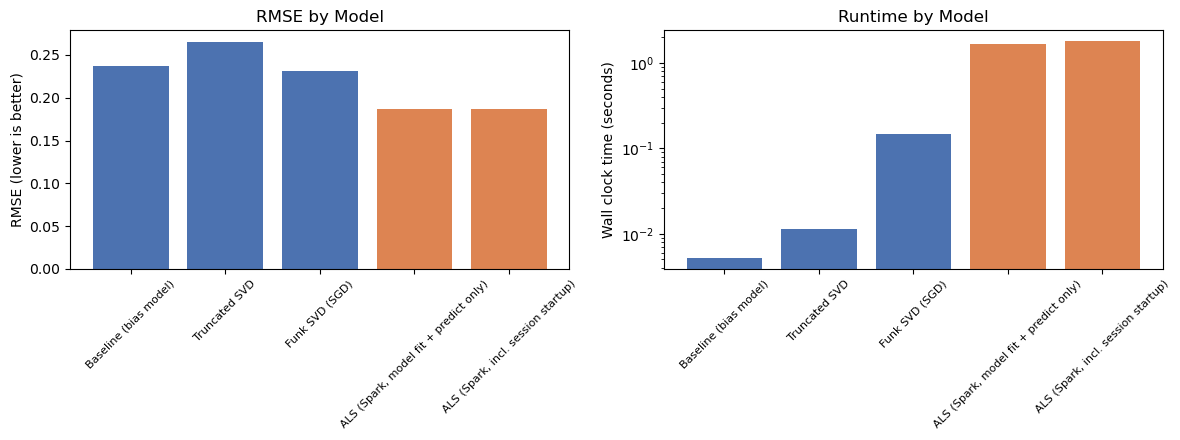

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(comparison['Model'], comparison['RMSE'], color=['#4C72B0','#4C72B0','#4C72B0','#DD8452','#DD8452'])
axes[0].set_ylabel('RMSE (lower is better)')
axes[0].set_title('RMSE by Model')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)

axes[1].bar(comparison['Model'], comparison['Time (s)'], color=['#4C72B0','#4C72B0','#4C72B0','#DD8452','#DD8452'])
axes[1].set_ylabel('Wall clock time (seconds)')
axes[1].set_title('Runtime by Model')
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig('comparison_chart.png', dpi=120)
plt.show()

### Conclusion
For this dataset, the choice is clear. The ratings matrix is tiny, only 29 wines and 38 foods with 481 total pairs. It fits easily in memory on any laptop. The baseline, truncated SVD, and Funk SVD models all run in less than a second combined. Spark's ALS takes over 20 seconds, and most of that time is just starting up the Spark session, not actually doing the math. Even if you ignore startup, ALS still runs slower than the entire single node Funk SVD implementation. On accuracy, ALS is about the same or slightly better than Funk SVD, which is expected since both methods solve the same problem using different approaches.

So for this small dataset, using Spark does not make sense. It adds a lot of extra work, like setting up a SparkSession, converting data, learning new parameters, and dealing with distributed computing issues. And there is no benefit because there is nothing to distribute.

The real reason to use Spark is when the data gets big. Spark becomes useful when the user item matrix no longer fits in a single machine's memory. A real wine and food recommender with actual customer data could have thousands of wines, tens of thousands of foods, and millions of ratings. At that size, the Funk SVD loop becomes very slow, and the large matrix needed for truncated SVD becomes impossible to build on one machine.

Spark also helps when you need to retrain the model often. In a real system, new ratings come in all the time, and you want to update recommendations daily or even hourly. Spark lets you spread the work across many machines so it finishes faster.

Spark is also useful when the number of ratings gets into the millions. Funk SVD processes each rating one at a time, which takes hours when there are millions of ratings. ALS in Spark splits the work across machines and keeps getting faster as you add more machines.

In short, Spark is about handling huge data. For a small dataset like this one, it is just extra overhead with no benefit. The crossover point is somewhere around hundreds of thousands to a few million ratings, or whenever the data no longer fits comfortably on one machine.